# Case 1: Klastering Kapasitas Finansial & Permodalan

Analisis ini bertujuan untuk memetakan UMKM berdasarkan kekuatan ekonomi dan akses mereka terhadap permodalan (Bantuan Pemerintah & Pinjaman Bank).

**Fokus Fitur yang Digunakan:**
- Omset Numeric
- Bantuan Pemerintah Numeric
- Pinjaman Bank Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [4]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Omset Numeric', 'Bantuan Pemerintah Numeric', 'Pinjaman Bank Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))



Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Omset Numeric,Bantuan Pemerintah Numeric,Pinjaman Bank Numeric
0,NASYWA SNACK,5.0,0,0
1,WARUNG ABINAYA,5.0,1,0
2,TUNGKU MA ENDANG,5.0,1,0
3,WARUNG BU WIWIK,5.0,0,0
4,WARUNG PNUNG,5.0,0,0


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


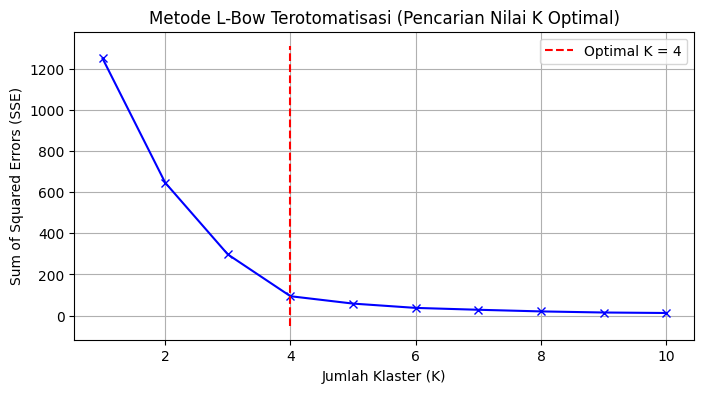

Rekomendasi K-Optimal adalah: 4


In [3]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi KMeans

In [4]:
print(f"Mengeksekusi K-Means Konvensional untuk K={optimal_k}...")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = kmeans.fit_predict(X_scaled)
final_centroids_scaled = kmeans.cluster_centers_


df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi K-Means Konvensional untuk K=4...


,Nama Usaha,Omset Numeric,Bantuan Pemerintah Numeric,Pinjaman Bank Numeric,Cluster
0,NASYWA SNACK,5.0,0,0,C2
1,WARUNG ABINAYA,5.0,1,0,C4
2,TUNGKU MA ENDANG,5.0,1,0,C4
3,WARUNG BU WIWIK,5.0,0,0,C2
4,WARUNG PNUNG,5.0,0,0,C2
5,KRISNA TRANSPORT,5.0,0,0,C2
6,LAUNDRY WINA,5.0,0,0,C2
7,JP CATERING,17.5,1,1,C1
8,SANDANG TRIAN,5.0,0,0,C2
9,JUALAN ES KELAPA MUDA,17.5,1,1,C1


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


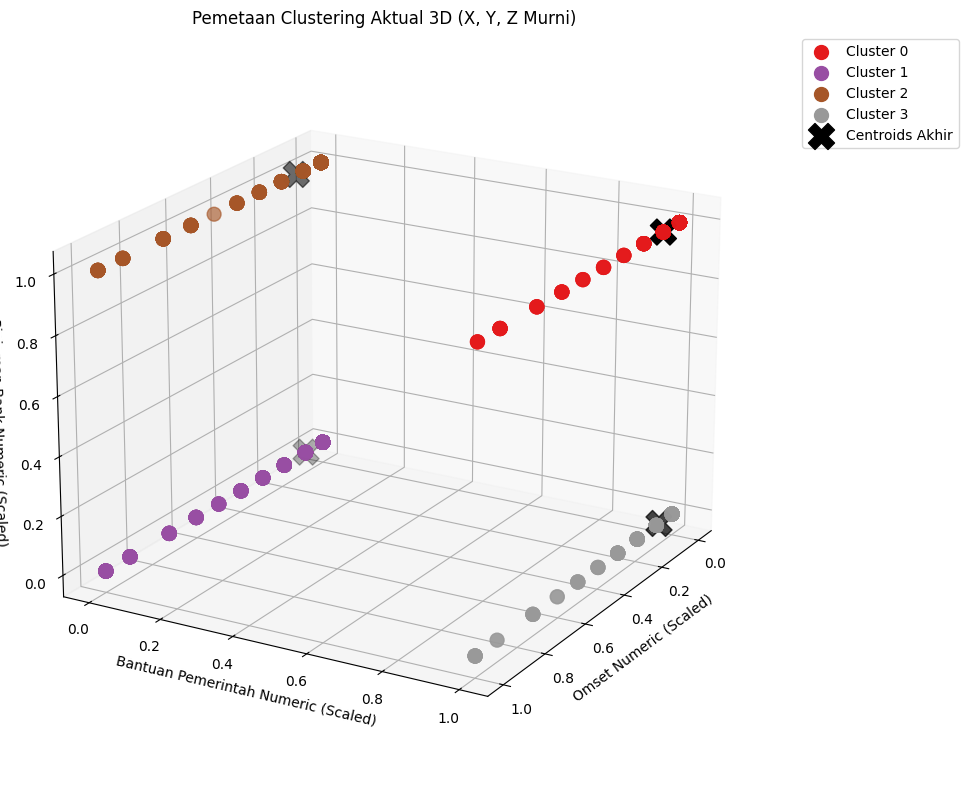


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.8683
   [Interpretasi]: SANGAT BAGUS. Data terstruktur dengan kokoh.

2. Davies-Bouldin Index (DBI): 0.2365
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 10695.1747
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 94.1898
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.1110
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [5]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [6]:
import plotly.express as px

# Membuat Scatter Plot 3D interaktif
fig_3d = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Omset Numeric
    y=fitur_yang_dipakai[1], # Bantuan Pemerintah Numeric
    z=fitur_yang_dipakai[2], # Pinjaman Bank Numeric
    color='Cluster',
    hover_name='Nama Usaha', # Menampilkan nama usaha saat kursor diarahkan ke titik
    title="Visualisasi Interaktif 3D Klastering Finansial",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1 # Palet warna yang cantik
)

# Merapikan margin
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()


In [7]:
# Menghitung nilai rata-rata tiap fitur untuk masing-masing klaster
df_avg = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Mengubah bentuk tabel (melt) agar mudah divisualisasikan oleh Plotly
df_melted = df_avg.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Fitur', value_name='Nilai Rata-rata')

# Membuat Grouped Bar Chart
fig_bar = px.bar(
    df_melted, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Fitur', 
    barmode='group',
    title="Profil Rata-rata Kapasitas Finansial per Klaster"
)
fig_bar.show()
